# Title: Predictive Modeling for Diabetes Risk Assessment

## Phase 1: Business Understanding

### 1.1 Introduction

### 1.2 Problem Statement

### 1.3 Objectives


## Phase 2: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
df_raw = pd.read_sas('LLCP2017.XPT', format='xport')
print(f'Raw dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Raw dataset shape: 450,016 rows x 358 columns


In [2]:
# create dataset based on selected features
cols = ['SEQNO', '_STATE', 'DIABETE3', '_AGEG5YR', 'SEX','_BMI5',
        '_FRTLT1A', '_VEGLT1A', '_RFDRHV5','_TOTINDA', '_SMOKER3', 
        '_MICHD', 'CHCKIDNY','CVDSTRK3', '_RFCHOL1', '_RFHYPE5', 'GENHLTH', 'MENTHLTH']
df = df_raw[cols].copy()
print(f'Subset shape: {df.shape}')
df.head()

Subset shape: (450016, 18)


,SEQNO,_STATE,DIABETE3,_AGEG5YR,SEX,_BMI5,_FRTLT1A,_VEGLT1A,_RFDRHV5,_TOTINDA,_SMOKER3,_MICHD,CHCKIDNY,CVDSTRK3,_RFCHOL1,_RFHYPE5,GENHLTH,MENTHLTH
0,b'2017000001',1.0,1.0,11.0,2.0,2696.0,1.0,1.0,1.0,1.0,4.0,2.0,2.0,2.0,2.0,2.0,2.0,88.0
1,b'2017000002',1.0,3.0,10.0,1.0,2943.0,1.0,1.0,1.0,1.0,4.0,2.0,2.0,2.0,1.0,2.0,2.0,88.0
2,b'2017000003',1.0,3.0,11.0,1.0,2504.0,2.0,2.0,1.0,2.0,4.0,2.0,2.0,2.0,2.0,1.0,3.0,88.0
3,b'2017000004',1.0,1.0,11.0,2.0,2663.0,2.0,9.0,1.0,9.0,4.0,2.0,2.0,2.0,2.0,2.0,4.0,88.0
4,b'2017000005',1.0,3.0,10.0,2.0,2330.0,1.0,2.0,1.0,2.0,3.0,2.0,2.0,2.0,1.0,1.0,4.0,88.0


In [3]:
# rename to readable snake_case
column_mapping = {
    'SEQNO':    'seqno',
    '_STATE':   'state_code',
    'DIABETE3':   'diabetes_status',
    '_AGEG5YR': 'age_group',
    'SEX':     'gender',
    '_BMI5':    'bmi',
    '_FRTLT1A': 'fruit_intake_daily',
    '_VEGLT1A': 'vegetable_intake_daily',
    '_RFDRHV5': 'heavy_drinker',
    '_TOTINDA': 'physical_activity',
    '_SMOKER3': 'smoker_status',
    '_MICHD'  : 'heart_disease_status',
    'CHCKIDNY': 'kidney_disease_status',
    'CVDSTRK3': 'stroke_status',
    '_RFCHOL1': 'cholesterol_status',
    '_RFHYPE5': 'hypertension_status',
    'GENHLTH':  'general_health_status',
    'MENTHLTH': 'mental_health_status',
}
df = df.rename(columns=column_mapping)
df.columns.tolist()

['seqno',
 'state_code',
 'diabetes_status',
 'age_group',
 'gender',
 'bmi',
 'fruit_intake_daily',
 'vegetable_intake_daily',
 'heavy_drinker',
 'physical_activity',
 'smoker_status',
 'heart_disease_status',
 'kidney_disease_status',
 'stroke_status',
 'cholesterol_status',
 'hypertension_status',
 'general_health_status',
 'mental_health_status']

### Constructing a true respondent-level identifier

In BRFSS, the **SEQNO (Annual Sequence Number) is unique only within a state**, not across the full file. Two genuinely different respondents in different states can share the same SEQNO. To get a globally unique respondent key, we concatenate state code and sequence number into **unique_id**.

In [4]:
# create unique_id by combining state code and sequence number
# cast to int first to strip the .0 from float64 (coz read_sas returns floats)
df['unique_id'] = (
    df['state_code'].astype(int).astype(str).str.zfill(2)
    + '_'
    + df['seqno'].astype(int).astype(str).str.zfill(10)
)

# every respondent should have their own unique_id
n_rows  = len(df)
n_uniq  = df['unique_id'].nunique()
n_dupes = n_rows - n_uniq
print(f'Total rows:          {n_rows:,}')
print(f'Distinct unique_ids: {n_uniq:,}')
print(f'Duplicate keys:      {n_dupes:,}')
assert n_dupes == 0, 'unique_id is not unique - investigate before proceeding'

# Show a sample
df[['unique_id', 'state_code', 'seqno']].head(3)

Total rows:          450,016
Distinct unique_ids: 450,016
Duplicate keys:      0


,unique_id,state_code,seqno
0,01_2017000001,1.0,b'2017000001'
1,01_2017000002,1.0,b'2017000002'
2,01_2017000003,1.0,b'2017000003'


We address four issues in order, each with explicit justification:
1. **Sentinel code recoding**
2. **Duplicate detection**
3. **Missing value handling**
4. **Outlier**

### Recoding BRFSS sentinel values and harmonising scales

BRFSS encodes:
- `7` = Don't know / Not sure
- `9` = Refused
- `77` and `99` = the same on longer-scale items
- `88` = "None" for count variables (such as zero poor-mental-health days)

If these special codes are left in the data, any mean, correlation, or model fit will be badly biased. We therefore map every special code to **NaN** before any statistical work. This recoding is the standard preparation step recommended by the CDC's official BRFSS documentation (Centers for Disease Control and Prevention, 2025) and by state-level BRFSS analysis guides such as the Montana BRFSS Data User Guide (Montana Department of Public Health and Human Services, 2023).

In [5]:
def preprocess_data(df):

    data = df.copy()

    # Target: diabetes_status 1 = Yes; 2,3,4 = No; 7/9 -> NaN
    # recode 1=Yes, 0=No and drop missing values
    data['diabetes_status'] = data['diabetes_status'].replace({2: 0, 3: 0, 4: 0})
    data.loc[data['diabetes_status'] > 1, 'diabetes_status'] = np.nan
    data = data.dropna(subset=['diabetes_status'])

    # Age group: 14 = Don't know / refused / missing -> NaN
    data.loc[data['age_group'] == 14, 'age_group'] = np.nan

    # Gender: 1=Male, 2=Female recode to 1=Male, 0=Female (binary), 9=Refused -> NaN
    data['gender'] = data['gender'].replace({2: 0})
    data.loc[data['gender'] == 9, 'gender'] = np.nan

    # BMI (_BMI5) is stored x100 (two implicit decimals) per BRFSS convention
    data['bmi'] = data['bmi'] / 100.0

     # Smoker status: 1=Daily, 2=Sometimes, 3=Former, 4=Never; 7/9 -> NaN
    data.loc[data['smoker_status'] > 4, 'smoker_status'] = np.nan

    # Heavy drinker: 1=No, 2=Yes; 9 -> NaN; harmonise to 1=Yes, 0=No
    data['heavy_drinker'] = data['heavy_drinker'].replace({1: 0, 2: 1})
    data.loc[data['heavy_drinker'] == 9, 'heavy_drinker'] = np.nan

    # cholesterol status: 1=No, 2=Yes; 7/9 -> NaN; harmonise to 1=Yes, 0=No
    data['cholesterol_status'] = data['cholesterol_status'].replace({1: 0, 2: 1})
    data.loc[data['cholesterol_status'] > 2, 'cholesterol_status'] = np.nan

    # hypertension status: 1=No, 2=Yes; 7/9 -> NaN; harmonise to 1=Yes, 0=No
    data['hypertension_status'] = data['hypertension_status'].replace({1: 0, 2: 1})
    data.loc[data['hypertension_status'] > 2, 'hypertension_status'] = np.nan

    # General health: 1=Excellent, 5=Poor; 7/9 -> NaN
    data.loc[data['general_health_status'] > 5, 'general_health_status'] = np.nan

    # Mental health days: 88 = "None" -> 0; 77/99 -> NaN; >30 invalid -> NaN
    data['mental_health_status'] = data['mental_health_status'].replace({88: 0})
    data.loc[data['mental_health_status'] > 30, 'mental_health_status'] = np.nan

    # Binary 1=Yes, 2=No, 7/9 -> NaN, recode 2 -> 0
    binary_cols = ['heart_disease_status', 'stroke_status', 'kidney_disease_status', 'physical_activity', 'fruit_intake_daily', 'vegetable_intake_daily']
    for col in binary_cols:
        data.loc[data[col] > 2, col] = np.nan
        data[col] = data[col].replace({2: 0})

    return data

data = preprocess_data(df)
print(f'After sentinel recoding: {data.shape[0]:,} rows x {data.shape[1]} columns')

After sentinel recoding: 449,219 rows x 19 columns


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449219 entries, 0 to 450015
Data columns (total 19 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   seqno                   449219 non-null  object 
 1   state_code              449219 non-null  float64
 2   diabetes_status         449219 non-null  float64
 3   age_group               443215 non-null  float64
 4   gender                  448943 non-null  float64
 5   bmi                     413007 non-null  float64
 6   fruit_intake_daily      410050 non-null  float64
 7   vegetable_intake_daily  401971 non-null  float64
 8   heavy_drinker           419179 non-null  float64
 9   physical_activity       415144 non-null  float64
 10  smoker_status           430594 non-null  float64
 11  heart_disease_status    445259 non-null  float64
 12  kidney_disease_status   447828 non-null  float64
 13  stroke_status           448007 non-null  float64
 14  cholesterol_status      3

In [7]:
# Count duplicates considering ALL columns including unique_id
n_dup_full = data.duplicated().sum()
print(f'number of duplicates:      {n_dup_full:,}')

# Count duplicates ignoring unique_id
n_dup_no_id = data.drop(columns=['unique_id', 'seqno', 'state_code']).duplicated().sum()
print(f'Pseudo-duplicates if we ignore identifiers: {n_dup_no_id:,}')
print(f'and thats roughly {100 * n_dup_no_id / len(data):.1f}% of rows')

number of duplicates:      0
Pseudo-duplicates if we ignore identifiers: 48,312
and thats roughly 10.8% of rows


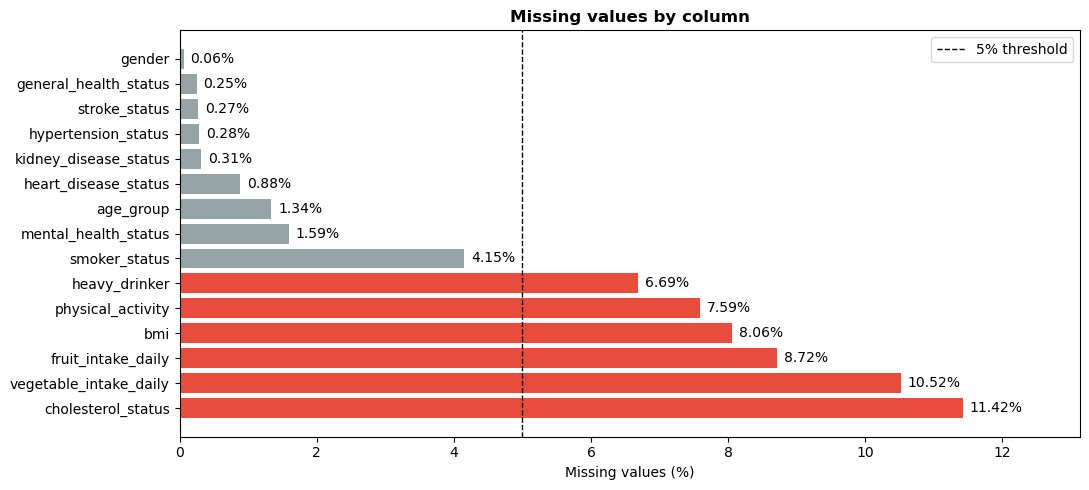

In [8]:
# check for missing values by column after preprocess
missing      = data.isna().sum().sort_values(ascending=False)
missing_pct  = (missing / len(data) * 100).round(2)
missing_plot = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    missing_plot.index,
    missing_plot.values,
    color=['#e74c3c' if v > 5 else '#95a5a6' for v in missing_plot.values],
)

ax.axvline(5, color='black', linestyle='--', lw=1, label='5% threshold')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missing values by column', fontweight='bold')

ax.set_xlim(0, missing_plot.max() * 1.15)

for bar, v in zip(bars, missing_plot.values):
    ax.text(bar.get_width() + 0.1,
            bar.get_y() + bar.get_height()/2,
            f'{v:.2f}%',
            va='center',
            fontsize=10)

ax.legend()
plt.tight_layout()
plt.show()

#### Listwise deletion for low-missingness variables (<1.5%)

We opted for listwise deletion for **gender, general_health_status, stroke_status, hypertension_status, kidney_disease_status, heart_disease_status, and age_group** because the proportion of missing data is too small to justify imputation, which would only add noise. Listwise deletion is both conservative and unbiased when missing data is rare and the MCAR assumption is reasonably met (Kang, 2013). This decision directly reflects the prevailing methodology in BRFSS-based diabetes prediction research, supported by Masconi et al.'s (2015) systematic review demonstrating that **43.8% of 48 comparable studies rely on case-wise deletion.**

In [9]:
listwise_drop_cols = [
    'gender', 'stroke_status', 'hypertension_status',
    'kidney_disease_status', 'general_health_status',
    'heart_disease_status', 'age_group',
]
n_before = len(data)
data = data.dropna(subset=listwise_drop_cols)
n_dropped = n_before - len(data)
print(f"Dropped {n_dropped:,} rows ({n_dropped/n_before*100:.2f}%) "
      f"with missing values")
print(f"Remaining: {len(data):,} rows")

Dropped 14,338 rows (3.19%) with missing values
Remaining: 434,881 rows


### Median / mode imputation for moderate missingness, inside an **sklearn Pipeline**

For the remaining variable with moderate missingness, we will apply:

- **Median** imputation for continuous variables: bmi, mental_health_status
- **Mode** imputation for categorical variables: cholesterol_status, physical_activity, heavy_drinker, smoker_status, fruit_intake_daily, vegetable_intake_daily

This is the dominant approach in recent BRFSS-based diabetes ML work. Khaleel et al. (2024) report that missing values in categorical variables such as Age and Physical Activity were imputed using the mode, and continuous variables were imputed using the median. These methods were particularly effective in maintaining dataset integrity.

Critically, the imputer is fit inside an **sklearn Pipeline after train_test_split** so that imputation statistics are learned from training data only. Fitting an imputer on the full dataset before splitting is a common but subtle source of data leakage. We deliberately prefer median/mode over Multiple Imputation by Chained Equations (MICE) for two reasons: 

1. Lin et al. (2023) in a Monte Carlo study run *specifically on BRFSS*, found that *"these three methods [MICE, hot-deck, GERBIL] did not always outperform listwise deletion in our simulated missing patterns"*, so MICE's benefits over simpler approaches are not guaranteed on BRFSS
2. for predictive ML on a large sample, simple imputation typically matches MICE in held-out performance while remaining trivially compatible with sklearn pipelines and cross-validation.



#### Add missingness indicator columns where refusal is informative

For **cholesterol_status, heavy_drinker, smoker_status, and physical_activity**, *refusal or don't know* is plausibly **not random**. People who never had their cholesterol checked, or who decline to discuss alcohol or smoking, differ systematically from those who answer. We therefore will add binary **was_missing** flags **before** imputation so the model can use the missingness pattern itself as a feature. This is the **missing-indicator method** (Groenwold et al., 2012), endorsed for predictive modelling by Sperrin et al. (2020) on the grounds that
*missing patterns may convey important information* in prediction tasks, where the objective is forecast accuracy on new data rather than estimating unbiased causal effects.

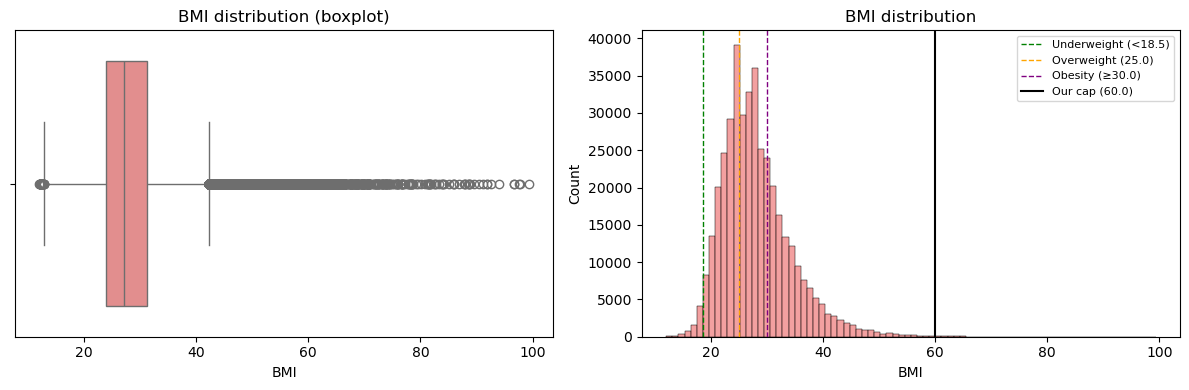

BMI summary statistics:
count    402397.000000
mean         28.161921
std           6.263916
min          12.010000
25%          23.890000
50%          27.200000
75%          31.240000
max          99.310000
Name: bmi, dtype: float64

Count BMI < 12: 0
Count BMI > 60: 528
Count BMI > 80: 42


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Boxplot of BMI, both for visual inspection and to see the whisker boundaries
sns.boxplot(x=data['bmi'], ax=axes[0], color='lightcoral')
axes[0].set_title('BMI distribution (boxplot)')
axes[0].set_xlabel('BMI')

sns.histplot(data['bmi'], bins=80, ax=axes[1], color='lightcoral')
axes[1].axvline(18.5, color='green', ls='--', lw=1, label='Underweight (<18.5)')
axes[1].axvline(25.0, color='orange', ls='--', lw=1, label='Overweight (25.0)')
axes[1].axvline(30.0, color='purple',    ls='--', lw=1, label='Obesity (≥30.0)')
axes[1].axvline(60.0, color='black',  ls='-',  lw=1.5, label='Our cap (60.0)')
axes[1].set_title('BMI distribution')
axes[1].set_xlabel('BMI')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print('BMI summary statistics:')
print(data['bmi'].describe())

# Count biologically-implausible extreme values
print(f"\nCount BMI < 12: {(data['bmi'] < 12).sum():,}")
print(f"Count BMI > 60: {(data['bmi'] > 60).sum():,}")
print(f"Count BMI > 80: {(data['bmi'] > 80).sum():,}")

We cap BMI to the biologically reasonable range of **12 to 60** (Winsorisation). This is preferred over deletion because:

1. **Deletion loses information.** A respondent reporting BMI = 65 is super obese. Their record contains real information about every other variable (age, diabetes, etc) so deleting them wastes that information.
2. **Winsorisation is a standard robust-statistics technique** (Tukey, 1962) that limits the influence of extreme values without removing records.
3. **Our chosen bounds are grounded in WHO body-mass classifications.** BMI 12 is the lower bound of severe medical anorexia in adults while BMI 60 is the upper bound of verified super-obesity cases.

We apply the cap and record how many rows were affected.

In [11]:
BMI_LOWER, BMI_UPPER = 12, 60
n_low  = (data['bmi'] < BMI_LOWER).sum()
n_high = (data['bmi'] > BMI_UPPER).sum()
data['bmi'] = data['bmi'].clip(lower=BMI_LOWER, upper=BMI_UPPER)
print(f'BMI winsorised to [{BMI_LOWER}, {BMI_UPPER}]: '
      f'{n_low} low values capped up, {n_high} high values capped down '
      f'({100*(n_low+n_high)/len(data):.3f}% of rows affected).')
print(f'BMI range after capping: [{data["bmi"].min():.2f}, {data["bmi"].max():.2f}]')

BMI winsorised to [12, 60]: 0 low values capped up, 528 high values capped down (0.121% of rows affected).
BMI range after capping: [12.01, 60.00]


# Exploratory Data Analysis

In [12]:
# build a display copy of the data with category labels for plotting
# We KEEP the numeric data untouched for modelling, df_plot is purely for visualisation
label_map = {
    'diabetes_status':       {0: 'No', 1: 'Yes'},
    'heart_disease_status':         {0: 'No', 1: 'Yes'},
    'stroke_status':         {0: 'No', 1: 'Yes'},
    'kidney_disease_status': {0: 'No', 1: 'Yes'},
    'physical_activity':     {0: 'Inactive', 1: 'Active'},
    'heavy_drinker':         {0: 'No', 1: 'Yes'},
    'gender':                {0: 'Female', 1: 'Male'},
    'cholesterol_status':     {0: 'No', 1: 'Yes'},
    'hypertension_status':    {0: 'No', 1: 'Yes'},
    'fruit_intake_daily':          {0: 'No', 1: 'Yes'},
    'vegetable_intake_daily':      {0: 'No', 1: 'Yes'},
    'general_health_status': {1: 'Excellent', 2: 'Very good', 3: 'Good', 4: 'Fair', 5: 'Poor'},
    'age_group':             {1: '18-24', 2: '25-29', 3: '30-34', 4: '35-39', 5: '40-44',
                              6: '45-49', 7: '50-54', 8: '55-59', 9: '60-64', 10: '65-69',
                              11: '70-74', 12: '75-79', 13: '80+'},
    'smoker_status':         {1: 'Daily', 2: 'Sometimes', 3: 'Former', 4: 'Never'}
}
df_plot = data.copy()
for col, m in label_map.items():
    df_plot[col] = df_plot[col].map(m)
df_plot.head()

,seqno,state_code,diabetes_status,age_group,gender,bmi,fruit_intake_daily,vegetable_intake_daily,heavy_drinker,physical_activity,smoker_status,heart_disease_status,kidney_disease_status,stroke_status,cholesterol_status,hypertension_status,general_health_status,mental_health_status,unique_id
0,b'2017000001',1.0,Yes,70-74,Female,26.96,Yes,Yes,No,Active,Never,No,No,No,Yes,Yes,Very good,0.0,01_2017000001
1,b'2017000002',1.0,No,65-69,Male,29.43,Yes,Yes,No,Active,Never,No,No,No,No,Yes,Very good,0.0,01_2017000002
2,b'2017000003',1.0,No,70-74,Male,25.04,No,No,No,Inactive,Never,No,No,No,Yes,No,Good,0.0,01_2017000003
3,b'2017000004',1.0,Yes,70-74,Female,26.63,No,NaN,No,NaN,Never,No,No,No,Yes,Yes,Fair,0.0,01_2017000004
4,b'2017000005',1.0,No,65-69,Female,23.30,Yes,No,No,Inactive,Former,No,No,No,No,No,Fair,0.0,01_2017000005


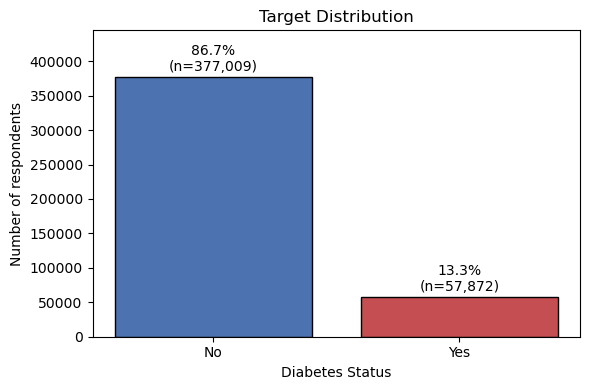

Diabetes prevalence in this dataset: 13.31%
Imbalance ratio (No : Yes): 6.5 : 1


In [13]:
# target variable distribution
fig, ax = plt.subplots(figsize=(6, 4))
target_counts = df_plot['diabetes_status'].value_counts()
bars = ax.bar(target_counts.index, target_counts.values,
              color=['#4C72B0', '#C44E52'], edgecolor='black')

total = target_counts.sum()

for bar, n in zip(bars, target_counts.values):
    perc = 100 * n / total
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + total * 0.02,
            f'{perc:.1f}%\n(n={n:,})',
            ha='center',
            fontsize=10)

ax.set_title('Target Distribution')
ax.set_xlabel('Diabetes Status')
ax.set_ylabel('Number of respondents')
ax.set_ylim(0, max(target_counts.values) * 1.18)

plt.tight_layout()
plt.show()

prevalence = data['diabetes_status'].mean() * 100
print(f'Diabetes prevalence in this dataset: {prevalence:.2f}%')
print(f'Imbalance ratio (No : Yes): {(data["diabetes_status"]==0).sum() / (data["diabetes_status"]==1).sum():.1f} : 1')

- The distribution shows a moderate class imbalance, with roughly 13.3 per cent of respondents reporting diabetes
- As a result, we cannot use accuracy as the primary success metric, and will prioritize using recall, ROC-AUC and F1 score during evaluation
- To ensure the model learns to identify diabetes effectively, we must implement techniques like SMOTE or class weighting during the training phase


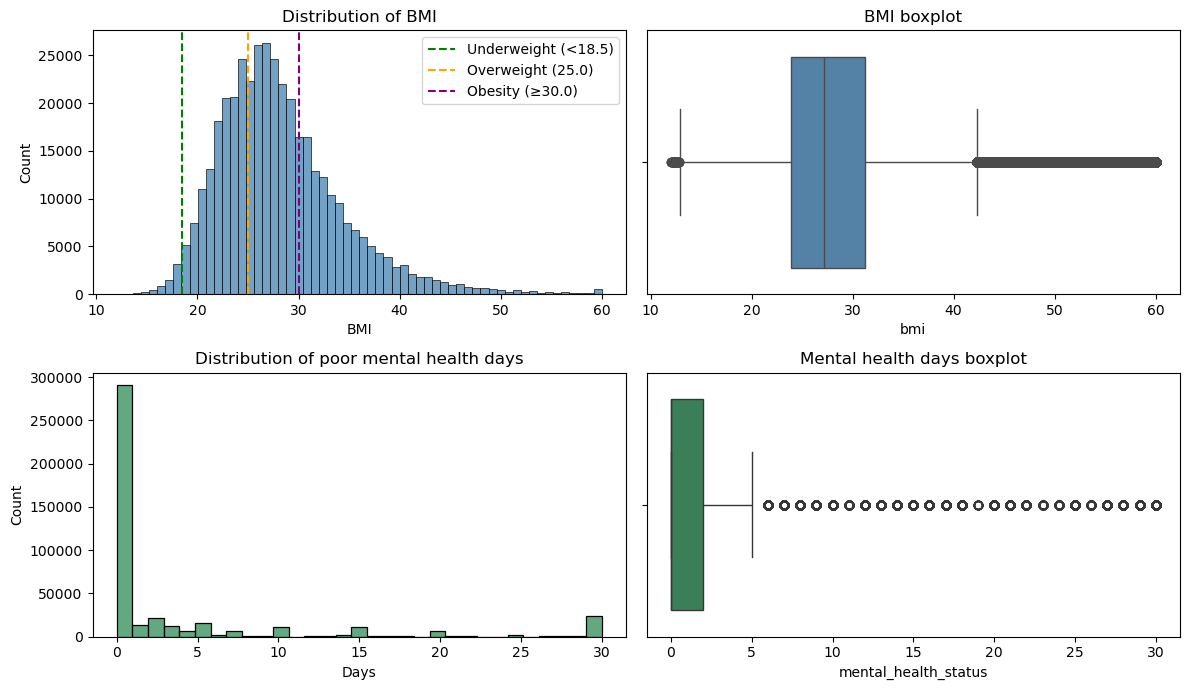

             bmi  mental_health_status
count  402397.00             428536.00
mean       28.15                  3.56
std         6.20                  7.86
min        12.01                  0.00
25%        23.89                  0.00
50%        27.20                  0.00
75%        31.24                  2.00
max        60.00                 30.00


In [14]:
# Continuous / count variables: histogram + boxplot
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
sns.histplot(data['bmi'], bins=60, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of BMI')
axes[0, 0].set_xlabel('BMI')

axes[0, 0].axvline(18.5, color='green',  ls='--', lw=1.5, label='Underweight (<18.5)')
axes[0, 0].axvline(25.0, color='orange', ls='--', lw=1.5, label='Overweight (25.0)')
axes[0, 0].axvline(30.0, color='purple', ls='--', lw=1.5, label='Obesity (≥30.0)')
axes[0, 0].legend()

sns.boxplot(x=data['bmi'], ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('BMI boxplot')

sns.histplot(data['mental_health_status'], bins=31, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Distribution of poor mental health days')
axes[1, 0].set_xlabel('Days')

sns.boxplot(x=data['mental_health_status'], ax=axes[1, 1], color='seagreen')
axes[1, 1].set_title('Mental health days boxplot')
plt.tight_layout()
plt.show()

print(data[['bmi', 'mental_health_status']].describe().round(2))

BMI:
- Right-skewed distribution with mean 28.15 above median 27.20, and IQR 23.89 to 31.24 showing the middle 50 percent fall in the overweight category
- Visible concentrations at BMI 12 and 60 are expected artifacts of winsorisation applied during outlier handling

Mental Health Days:
- Majority of the respondent reported zero poor mental health days, with the median and Q1 both at zero
- Although most report no distress, the mean 3.56 and standard deviation 7.86 are pulled upward by a smaller subgroup with many distress days
- A secondary peak reflects respondents reporting daily distress for the entire month, identifying a chronically distressed subgroup

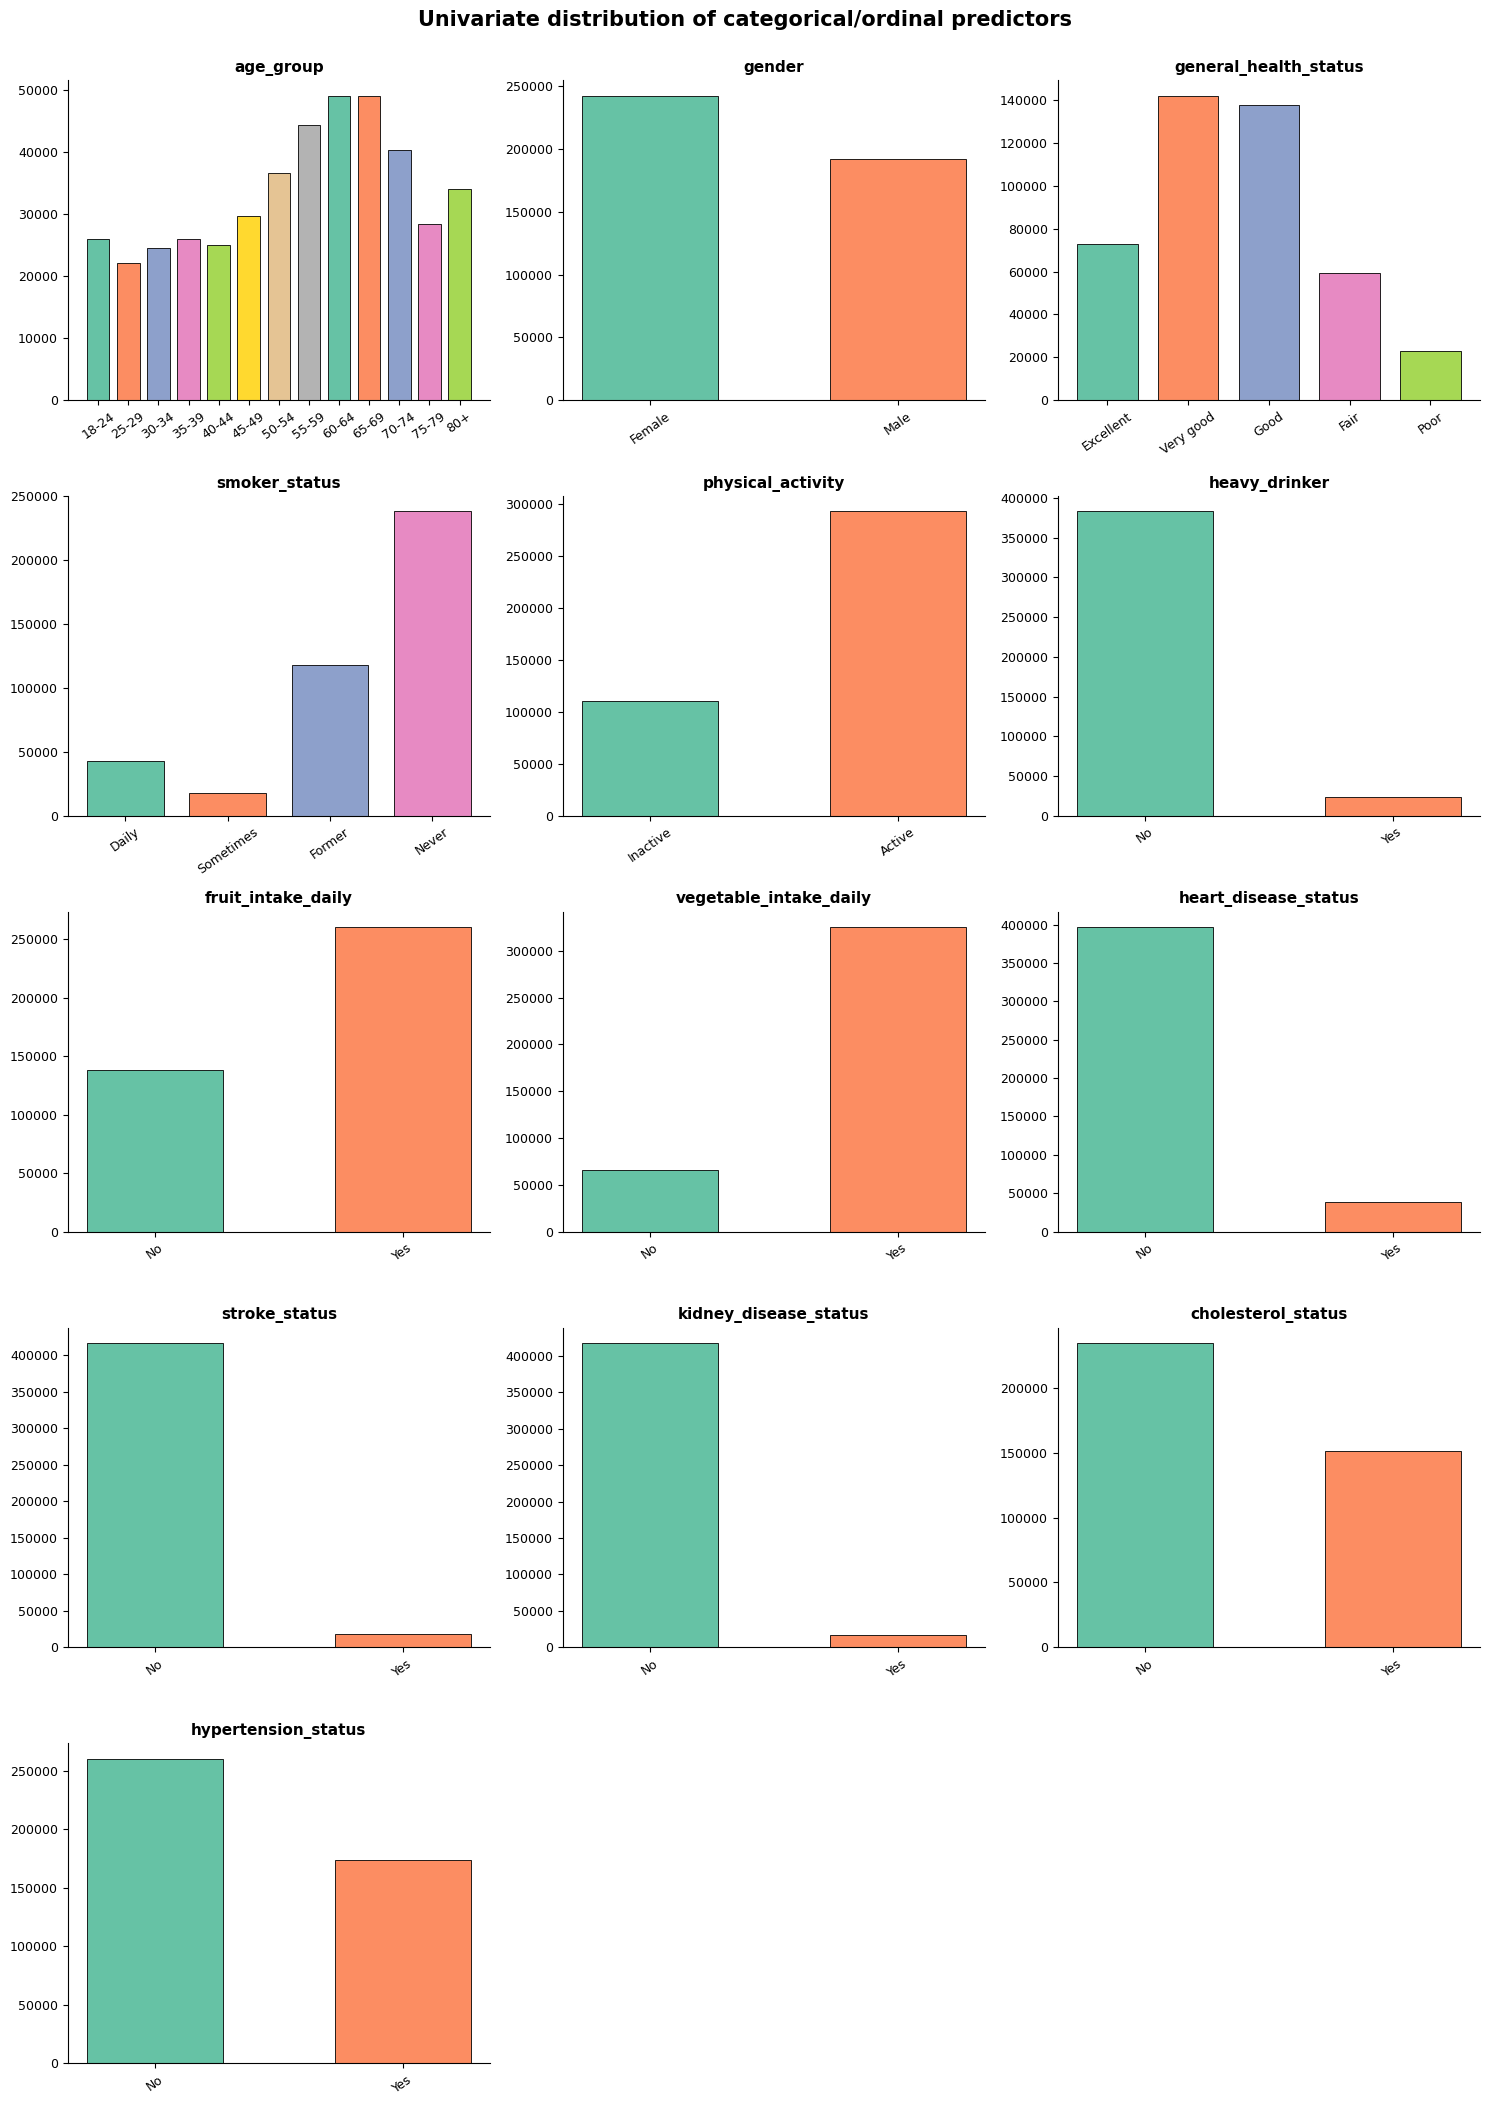

In [15]:
cat_vars = ['age_group', 'gender', 'general_health_status', 'smoker_status',
            'physical_activity', 'heavy_drinker',
            'fruit_intake_daily', 'vegetable_intake_daily',
            'heart_disease_status', 'stroke_status', 'kidney_disease_status',
            'cholesterol_status', 'hypertension_status']

category_orders = {
    'age_group': ['18-24','25-29','30-34','35-39','40-44','45-49','50-54',
                  '55-59','60-64','65-69','70-74','75-79','80+'],
    'general_health_status': ['Excellent','Very good','Good','Fair','Poor'],
    'smoker_status': ['Daily','Sometimes','Former','Never'],
    'gender': ['Female', 'Male'],
    'physical_activity': ['Inactive', 'Active'],
    'heavy_drinker': ['No', 'Yes'],
    'fruit_intake_daily': ['No', 'Yes'],
    'vegetable_intake_daily': ['No', 'Yes'],
    'heart_disease_status': ['No','Yes'],
    'stroke_status': ['No','Yes'],
    'kidney_disease_status': ['No','Yes'],
    'cholesterol_status': ['No','Yes'],
    'hypertension_status': ['No','Yes'],
}

n_cols = 3
n_rows = -(-len(cat_vars) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.2 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ax = axes[i]
    counts = df_plot[col].value_counts()
    if col in category_orders:
        counts = counts.reindex(category_orders[col])

    bar_width = 0.55 if len(counts) <= 3 else 0.75
    colors = sns.color_palette('Set2', len(counts))

    ax.bar(counts.index.astype(str), counts.values,
           width=bar_width, color=colors,
           edgecolor='black', linewidth=0.6)

    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

for j in range(len(cat_vars), len(axes)):
    axes[j].axis('off')

plt.suptitle('Univariate distribution of categorical/ordinal predictors',
             fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

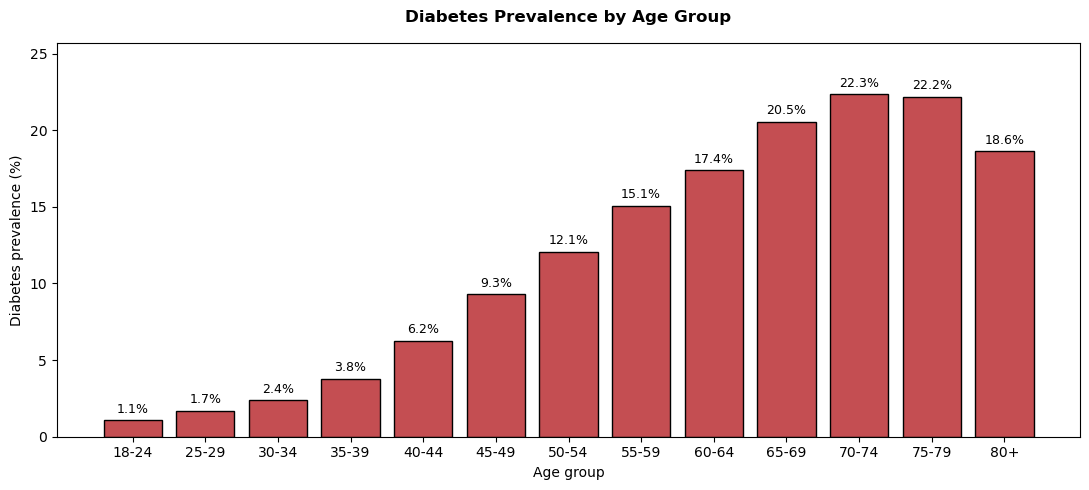

In [16]:
# Diabetes prevalence by age group
age_order = ['18-24','25-29','30-34','35-39','40-44','45-49',
             '50-54','55-59','60-64','65-69','70-74','75-79','80+']

age_hd = (df_plot.groupby('age_group')['diabetes_status']
          .value_counts(normalize=True)
          .mul(100)
          .rename('pct')
          .reset_index())

age_hd_yes = (age_hd[age_hd['diabetes_status'] == 'Yes']
              .set_index('age_group').reindex(age_order)
              .reset_index())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(age_hd_yes['age_group'], age_hd_yes['pct'],
              color='#C44E52', edgecolor='black')

for bar, pct in zip(bars, age_hd_yes['pct']):
    if not np.isnan(pct):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', fontsize=9)

ax.set_title('Diabetes Prevalence by Age Group', fontweight='bold', pad=15)
ax.set_xlabel('Age group')
ax.set_ylabel('Diabetes prevalence (%)')
ax.set_ylim(0, age_hd_yes['pct'].max() * 1.15)

plt.tight_layout()
plt.show()

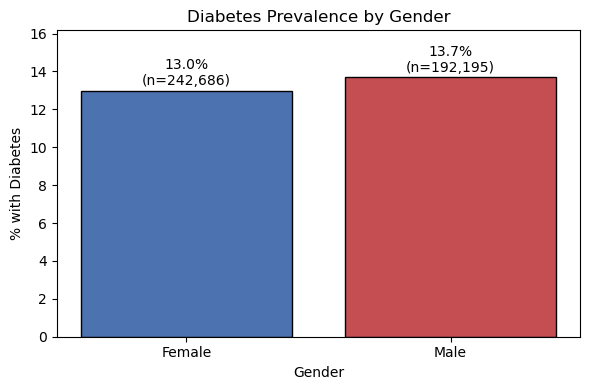

Female: 12.99% prevalence (n=242,686)
Male: 13.71% prevalence (n=192,195)


In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

# % of each gender that has diabetes
gender_prev = df_plot.groupby('gender')['diabetes_status'].apply(
    lambda x: (x == 'Yes').mean() * 100
)
gender_counts = df_plot.groupby('gender').size()

bars = ax.bar(gender_prev.index, gender_prev.values,
              color=['#4C72B0', '#C44E52'], edgecolor='black')

for bar, pct, n in zip(bars, gender_prev.values, gender_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(gender_prev.values)*0.02,
            f'{pct:.1f}%\n(n={n:,})', ha='center', fontsize=10)

ax.set_title('Diabetes Prevalence by Gender')
ax.set_xlabel('Gender')
ax.set_ylabel('% with Diabetes')
ax.set_ylim(0, max(gender_prev.values) * 1.18)
plt.tight_layout()
plt.show()

# Summary stats
for g in gender_prev.index:
    print(f'{g}: {gender_prev[g]:.2f}% prevalence (n={gender_counts[g]:,})')
diff = gender_prev.max() - gender_prev.min()

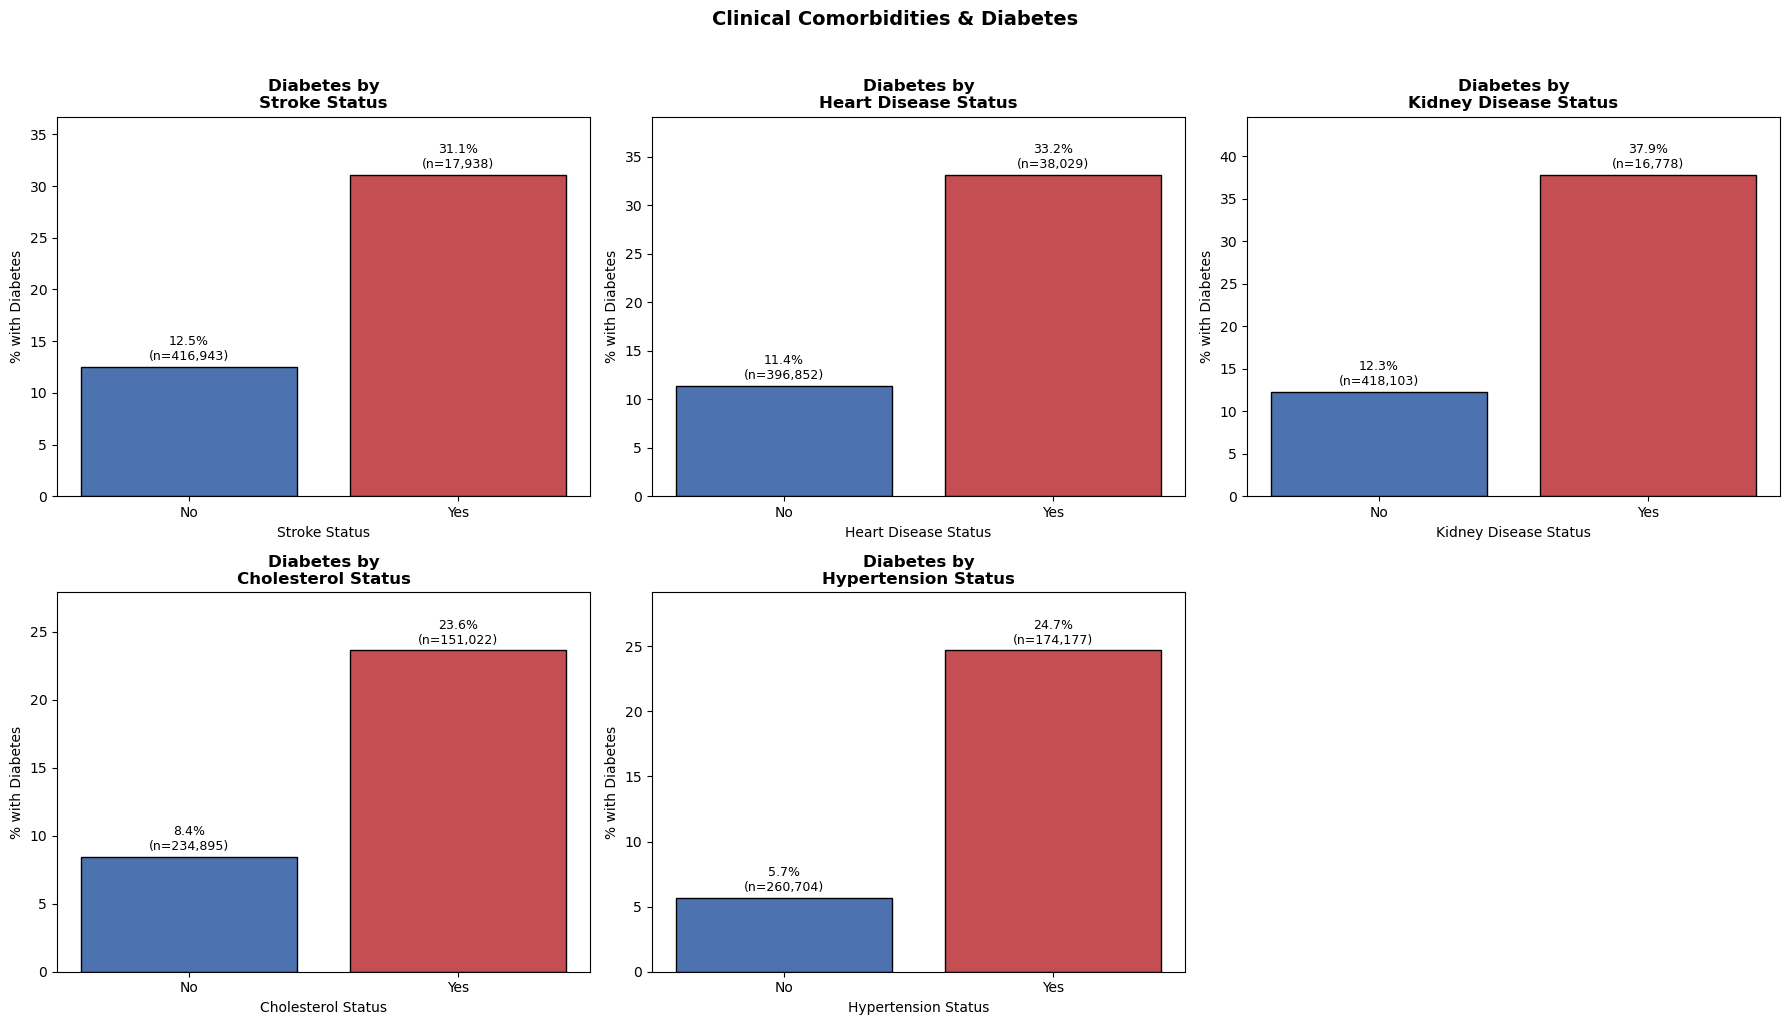


Stroke Status:
  No: 12.54% prevalence (n=416,943)
  Yes: 31.10% prevalence (n=17,938)
  Prevalence gap: 18.56 percentage points

Heart Disease Status:
  No: 11.40% prevalence (n=396,852)
  Yes: 33.17% prevalence (n=38,029)
  Prevalence gap: 21.77 percentage points

Kidney Disease Status:
  No: 12.32% prevalence (n=418,103)
  Yes: 37.85% prevalence (n=16,778)
  Prevalence gap: 25.53 percentage points

Cholesterol Status:
  No: 8.45% prevalence (n=234,895)
  Yes: 23.64% prevalence (n=151,022)
  Prevalence gap: 15.19 percentage points

Hypertension Status:
  No: 5.70% prevalence (n=260,704)
  Yes: 24.70% prevalence (n=174,177)
  Prevalence gap: 19.00 percentage points


In [18]:
# Diabetes prevalence by binary clinical conditions
binary_clinical = ['stroke_status', 'heart_disease_status', 'kidney_disease_status', 'cholesterol_status', 'hypertension_status']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for i, col in enumerate(binary_clinical):
    ax = axes_flat[i]
    
    # Prevalence and group size for each category in the condition
    prev = df_plot.groupby(col)['diabetes_status'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
    counts = df_plot.groupby(col).size()

    bars = ax.bar(prev.index.astype(str), prev.values,
                  color=['#4C72B0', '#C44E52'], edgecolor='black')

    for bar, pct, n in zip(bars, prev.values, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(prev.values)*0.02,
                f'{pct:.1f}%\n(n={n:,})', ha='center', fontsize=9)

    ax.set_title(f'Diabetes by\n{col.replace("_", " ").title()}',
                 fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.set_ylabel('% with Diabetes')
    ax.set_ylim(0, max(prev.values) * 1.18)

axes_flat[5].set_visible(False)

plt.suptitle('Clinical Comorbidities & Diabetes',
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Summary stats per condition
for col in binary_clinical:
    prev = df_plot.groupby(col)['diabetes_status'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
    counts = df_plot.groupby(col).size()
    print(f'\n{col.replace("_", " ").title()}:')
    for cat in prev.index:
        print(f'  {cat}: {prev[cat]:.2f}% prevalence (n={counts[cat]:,})')
    gap = prev.max() - prev.min()
    print(f'  Prevalence gap: {gap:.2f} percentage points')

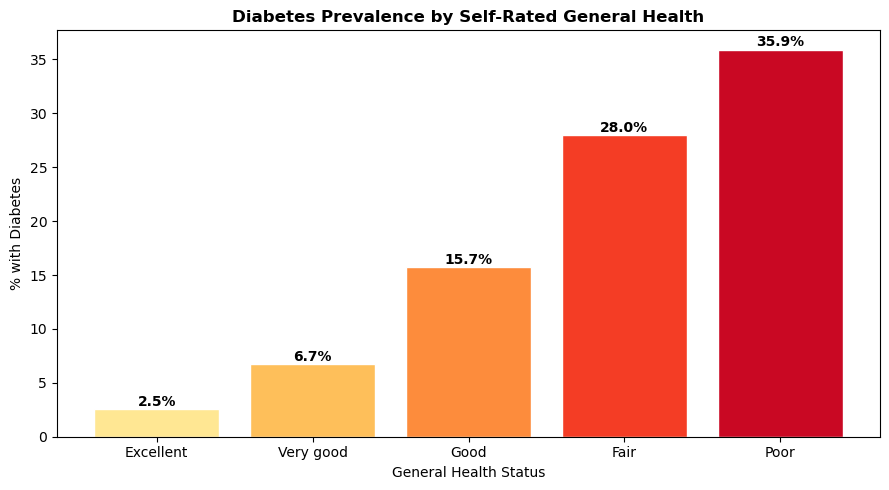

Prevalence in Excellent self-rated: 2.54%
Prevalence in Poor self-rated:      35.90%
Ratio (Poor / Excellent): 14.2x


In [19]:
# General health status
gh_order = ['Excellent', 'Very good', 'Good', 'Fair', 'Poor']
gh_hd = (df_plot.groupby('general_health_status')['diabetes_status']
         .value_counts(normalize=True).mul(100)
         .rename('pct').reset_index())
gh_yes = (gh_hd[gh_hd['diabetes_status']=='Yes']
          .set_index('general_health_status').reindex(gh_order)
          .reset_index())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(gh_yes['general_health_status'], gh_yes['pct'],
              color=sns.color_palette('YlOrRd', 5), edgecolor='white')
ax.set_title('Diabetes Prevalence by Self-Rated General Health', fontweight='bold')
ax.set_xlabel('General Health Status')
ax.set_ylabel('% with Diabetes')
for bar, val in zip(bars, gh_yes['pct'].fillna(0)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute the gradient
ex_pct = gh_yes.loc[gh_yes['general_health_status']=='Excellent', 'pct'].values[0]
poor_pct = gh_yes.loc[gh_yes['general_health_status']=='Poor', 'pct'].values[0]
print(f'Prevalence in Excellent self-rated: {ex_pct:.2f}%')
print(f'Prevalence in Poor self-rated:      {poor_pct:.2f}%')
print(f'Ratio (Poor / Excellent): {poor_pct/ex_pct:.1f}x')

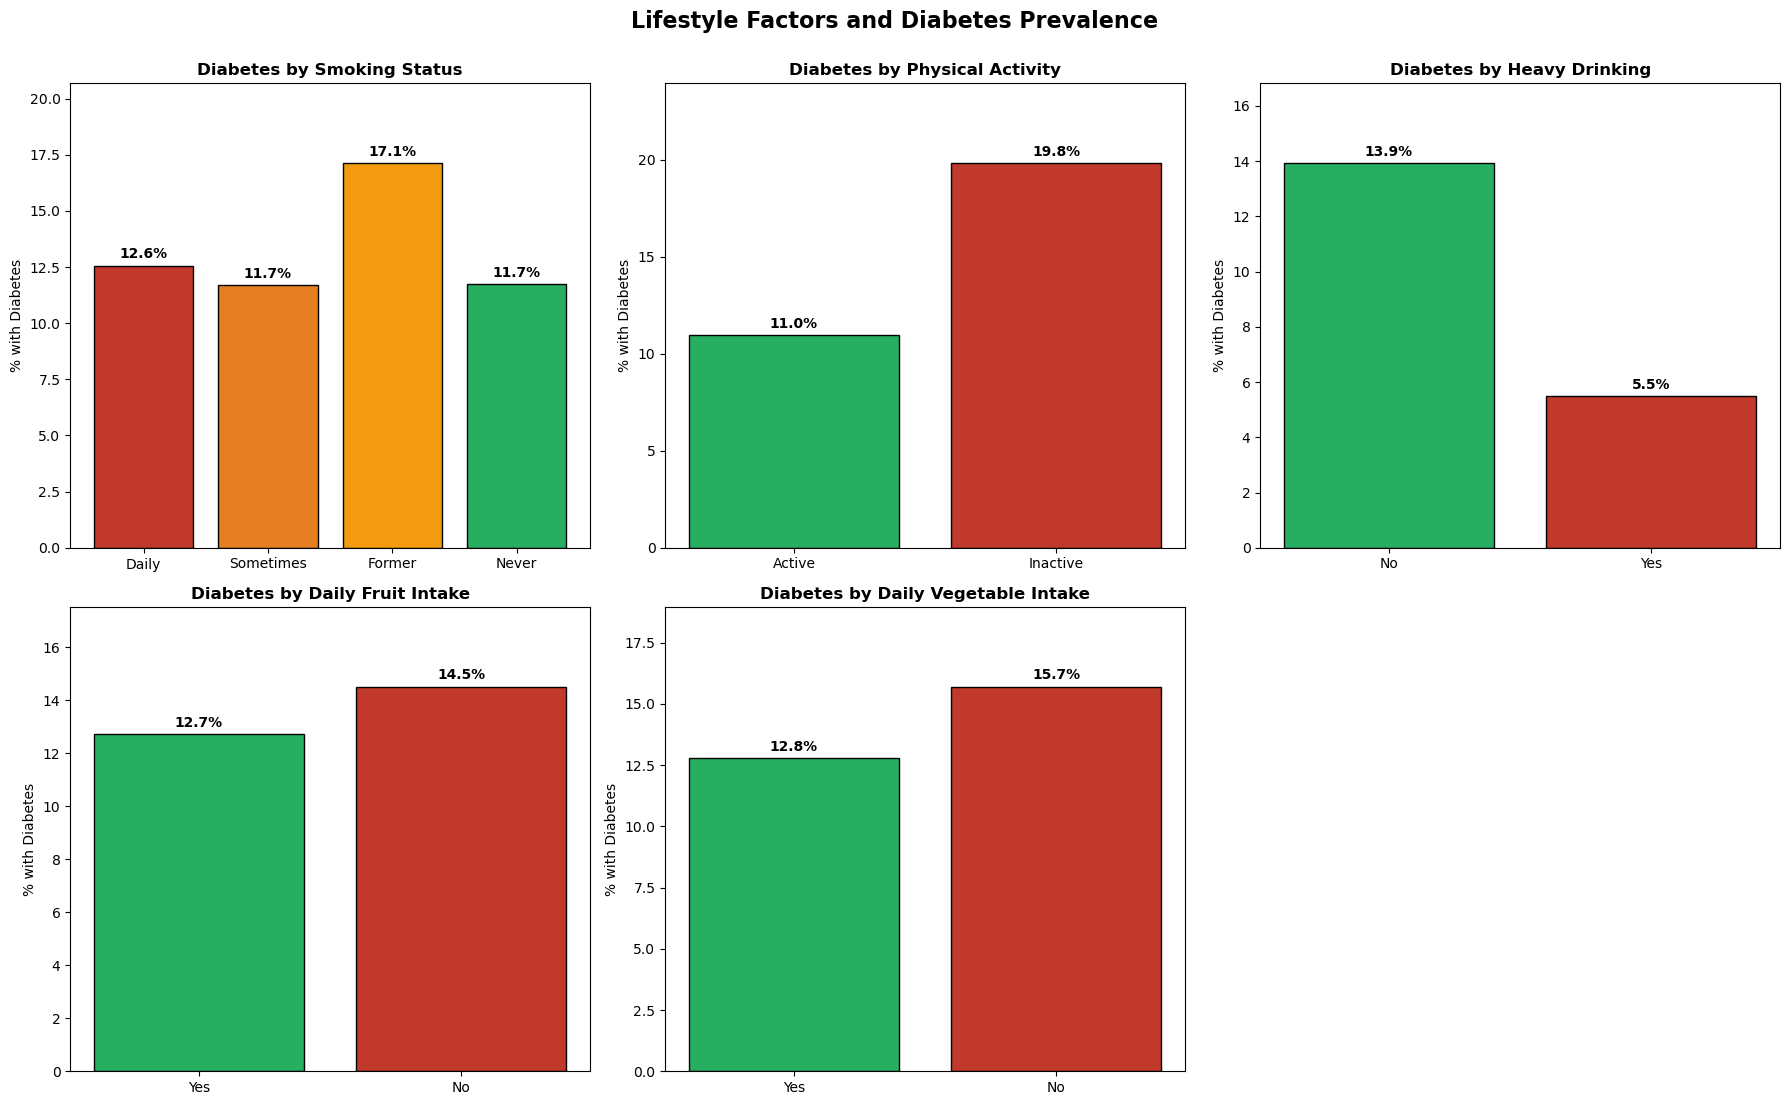

In [20]:
# Setup for the 5 subplots 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

# smoker status
smoke_order = ['Daily', 'Sometimes', 'Former', 'Never']
smoke_stats = (df_plot.groupby('smoker_status')['diabetes_status']
               .value_counts(normalize=True).mul(100)
               .unstack(fill_value=0))
smoke_stats = smoke_stats.reindex(smoke_order)
bars0 = axes[0].bar(smoke_stats.index, smoke_stats['Yes'],
                    color=['#c0392b','#e67e22','#f39c12','#27ae60'], edgecolor='black')
axes[0].set_title('Diabetes by Smoking Status', fontweight='bold')
axes[0].set_ylabel('% with Diabetes')
axes[0].bar_label(bars0, labels=[f'{v:.1f}%' for v in smoke_stats['Yes']],
                  padding=3, fontweight='bold')

# physical activity
pa_order = ['Active', 'Inactive']
pa_stats = (df_plot.groupby('physical_activity')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
pa_stats = pa_stats.reindex(pa_order)
bars1 = axes[1].bar(pa_stats.index, pa_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[1].set_title('Diabetes by Physical Activity', fontweight='bold')
axes[1].set_ylabel('% with Diabetes')
axes[1].bar_label(bars1, labels=[f'{v:.1f}%' for v in pa_stats['Yes']],
                  padding=3, fontweight='bold')

# heavy drinker
hd_order = ['No', 'Yes']
hd_stats = (df_plot.groupby('heavy_drinker')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
hd_stats = hd_stats.reindex(hd_order)
bars2 = axes[2].bar(hd_stats.index, hd_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[2].set_title('Diabetes by Heavy Drinking', fontweight='bold')
axes[2].set_ylabel('% with Diabetes')
axes[2].bar_label(bars2, labels=[f'{v:.1f}%' for v in hd_stats['Yes']],
                  padding=3, fontweight='bold')

# daily fruit intake
fr_order = ['Yes', 'No']
fr_stats = (df_plot.groupby('fruit_intake_daily')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
fr_stats = fr_stats.reindex(fr_order)
bars3 = axes[3].bar(fr_stats.index, fr_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[3].set_title('Diabetes by Daily Fruit Intake', fontweight='bold')
axes[3].set_ylabel('% with Diabetes')
axes[3].bar_label(bars3, labels=[f'{v:.1f}%' for v in fr_stats['Yes']],
                  padding=3, fontweight='bold')

# daily vegetable intake
vg_order = ['Yes', 'No']
vg_stats = (df_plot.groupby('vegetable_intake_daily')['diabetes_status']
            .value_counts(normalize=True).mul(100)
            .unstack(fill_value=0))
vg_stats = vg_stats.reindex(vg_order)
bars4 = axes[4].bar(vg_stats.index, vg_stats['Yes'],
                    color=['#27ae60', '#c0392b'], edgecolor='black')
axes[4].set_title('Diabetes by Daily Vegetable Intake', fontweight='bold')
axes[4].set_ylabel('% with Diabetes')
axes[4].bar_label(bars4, labels=[f'{v:.1f}%' for v in vg_stats['Yes']],
                  padding=3, fontweight='bold')

axes[5].axis('off')
for ax in axes[:5]:
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

plt.suptitle('Lifestyle Factors and Diabetes Prevalence',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

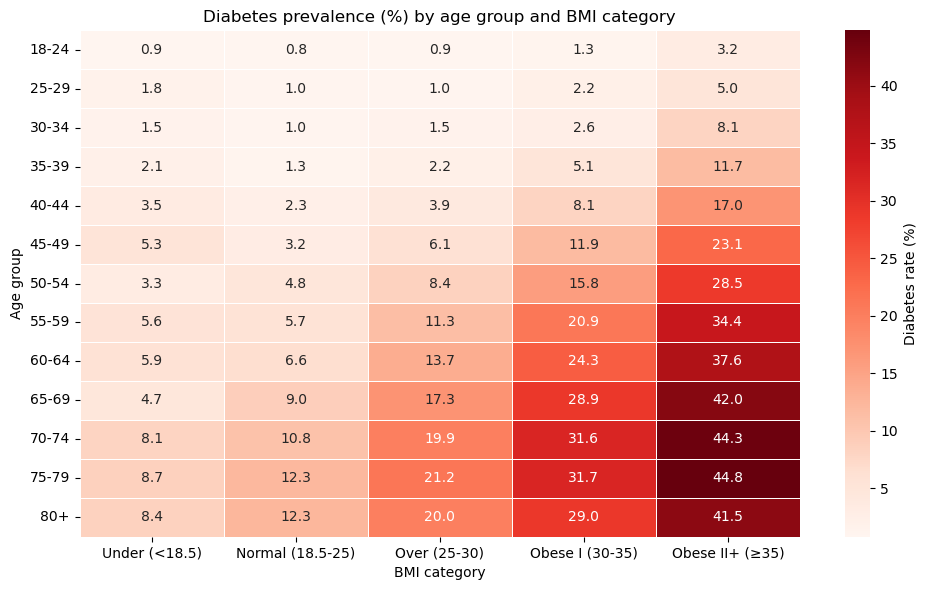

In [21]:
bmi_bins   = [0, 18.5, 25, 30, 35, 100]
bmi_labels = ['Under (<18.5)', 'Normal (18.5-25)', 'Over (25-30)',
              'Obese I (30-35)', 'Obese II+ (≥35)']
tmp = data.copy()
tmp['_bmi_cat'] = pd.cut(tmp['bmi'], bins=bmi_bins, labels=bmi_labels, right=False)

heat = (tmp.groupby(['age_group','_bmi_cat'], observed=True)['diabetes_status']
           .mean().unstack() * 100)
heat.index = [label_map['age_group'][int(i)] for i in heat.index]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='Reds',
            cbar_kws={'label': 'Diabetes rate (%)'},
            linewidth=0.5, linecolor='white', ax=ax)
ax.set_title('Diabetes prevalence (%) by age group and BMI category')
ax.set_xlabel('BMI category')
ax.set_ylabel('Age group')
plt.tight_layout()
plt.show()

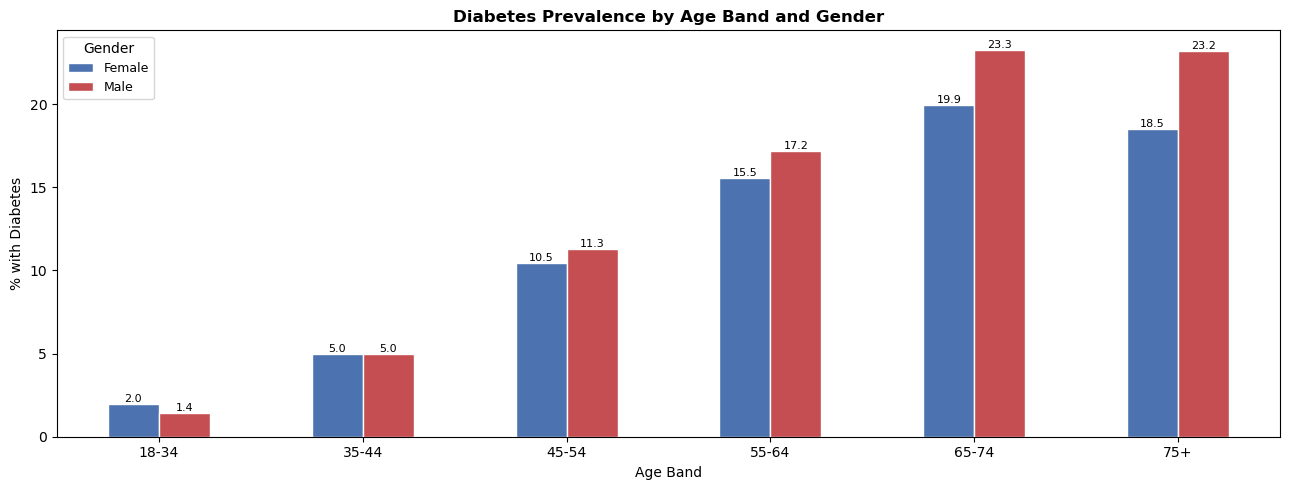

Diabetes prevalence (%) by age band and gender:
gender_label  Female   Male
age_band                   
18-34           1.96   1.44
35-44           4.99   5.00
45-54          10.45  11.27
55-64          15.54  17.19
65-74          19.94  23.27
75+            18.51  23.20

Male-to-Female prevalence ratio by age band:
gender_label  M:F ratio
age_band               
18-34              0.74
35-44              1.00
45-54              1.08
55-64              1.11
65-74              1.17
75+                1.25


In [22]:
# Heart disease prevalence by age band and gender
data_strat = data.copy()
data_strat['age_group_label'] = data_strat['age_group'].map(label_map['age_group'])

# Group ages into broader bands for cleaner plot
def age_band(a):
    if a in ['18-24','25-29','30-34']:return '18-34'
    elif a in ['35-39','40-44']:return '35-44'
    elif a in ['45-49','50-54']:return '45-54'
    elif a in ['55-59','60-64']:return '55-64'
    elif a in ['65-69','70-74']:return '65-74'
    else:return '75+'

data_strat['age_band'] = data_strat['age_group_label'].apply(age_band)
data_strat['gender_label'] = data_strat['gender'].map(label_map['gender'])
strat_g = (data_strat.groupby(['age_band', 'gender_label'])['diabetes_status']
           .mean().mul(100).reset_index(name='prevalence'))

pivot_g = strat_g.pivot(index='age_band', columns='gender_label', values='prevalence')
pivot_g = pivot_g.reindex(['18-34','35-44','45-54','55-64','65-74','75+'])
pivot_g = pivot_g[['Female', 'Male']]

fig, ax = plt.subplots(figsize=(13, 5))
pivot_g.plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'], edgecolor='white')
ax.set_title('Diabetes Prevalence by Age Band and Gender',
             fontweight='bold')
ax.set_xlabel('Age Band')
ax.set_ylabel('% with Diabetes')
ax.legend(title='Gender', fontsize=9)
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8)
plt.tight_layout()
plt.show()

print('Diabetes prevalence (%) by age band and gender:')
print(pivot_g.round(2))

# Compute male-to-female ratio to quantify how the gender gap changes with age
pivot_g['M:F ratio'] = (pivot_g['Male'] / pivot_g['Female']).round(2)
print('\nMale-to-Female prevalence ratio by age band:')
print(pivot_g[['M:F ratio']])

# Correlation analysis with the target

Three complementary measures because predictors mix continuous, ordinal, and nominal types:
1. Mutual information       - any feature type, captures nonlinearity
2. Bias-corrected Cramer's V - effect size for categorical features
3. Point-biserial / Spearman - continuous features vs binary target

In [23]:
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency, pointbiserialr, spearmanr

CONTINUOUS = ['bmi', 'mental_health_status']
CATEGORICAL = ['age_group', 'gender', 'fruit_intake_daily', 'vegetable_intake_daily',
               'heavy_drinker', 'physical_activity', 'smoker_status',
               'heart_disease_status', 'kidney_disease_status', 'stroke_status',
               'cholesterol_status', 'hypertension_status', 'general_health_status']
FEATURES = CATEGORICAL + CONTINUOUS
TARGET = 'diabetes_status'

# Throwaway imputed copy for EDA only
# The model pipeline still fits its imputer on TRAIN data after
# train_test_split, so this copy does NOT leak into modelling
data_eda = data.copy()
for c in ['bmi', 'mental_health_status']:
    data_eda[c] = data_eda[c].fillna(data_eda[c].median())
for c in ['cholesterol_status', 'physical_activity', 'heavy_drinker',
          'smoker_status', 'fruit_intake_daily', 'vegetable_intake_daily']:
    data_eda[c] = data_eda[c].fillna(data_eda[c].mode().iloc[0])

assert data_eda[FEATURES + [TARGET]].isna().sum().sum() == 0, \
    'Unexpected NaNs remain in data_eda'

# Mutual information
discrete_mask = [c in CATEGORICAL for c in FEATURES]
mi = mutual_info_classif(
    data_eda[FEATURES],
    data_eda[TARGET].astype(int),
    discrete_features=discrete_mask,
    random_state=42,
)
mi_df = (pd.DataFrame({'feature': FEATURES, 'mutual_info': mi})
           .sort_values('mutual_info', ascending=False)
           .reset_index(drop=True))

# Bias-corrected Cramer's V 
# Bias correction matters because age_group has 13 levels
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, k = ct.shape
    phi2_corr = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

v_df = (pd.DataFrame({
            'feature': CATEGORICAL,
            'cramers_v': [cramers_v(data_eda[c], data_eda[TARGET])
                          for c in CATEGORICAL],
        })
        .sort_values('cramers_v', ascending=False)
        .reset_index(drop=True))

# Continuous features vs binary target
# Point-biserial = Pearson with one binary variable (gives sign)
# Spearman is a rank-based sanity check
cont_df = pd.DataFrame([{
    'feature': c,
    'point_biserial_r': pointbiserialr(data_eda[TARGET], data_eda[c]).statistic,
    'spearman_rho':     spearmanr(data_eda[TARGET], data_eda[c]).statistic,
} for c in CONTINUOUS])

# Display results
print('Mutual information against diabetes_status')
print(mi_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nCramer\'s V (categorical features against diabetes_status)')
print(v_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\nContinuous features against diabetes_status')
print(cont_df.to_string(index=False, float_format=lambda x: f'{x:+.4f}'))



Mutual information against diabetes_status
               feature  mutual_info
 general_health_status       0.0388
   hypertension_status       0.0373
             age_group       0.0288
                   bmi       0.0265
    cholesterol_status       0.0233
  heart_disease_status       0.0128
 kidney_disease_status       0.0077
     physical_activity       0.0058
         stroke_status       0.0046
  mental_health_status       0.0027
         smoker_status       0.0023
         heavy_drinker       0.0019
vegetable_intake_daily       0.0004
    fruit_intake_daily       0.0003
                gender       0.0001

Cramer's V (categorical features against diabetes_status)
               feature  cramers_v
 general_health_status     0.2817
   hypertension_status     0.2741
    cholesterol_status     0.2218
             age_group     0.2183
  heart_disease_status     0.1810
 kidney_disease_status     0.1448
     physical_activity     0.1121
         stroke_status     0.1087
         smoker_

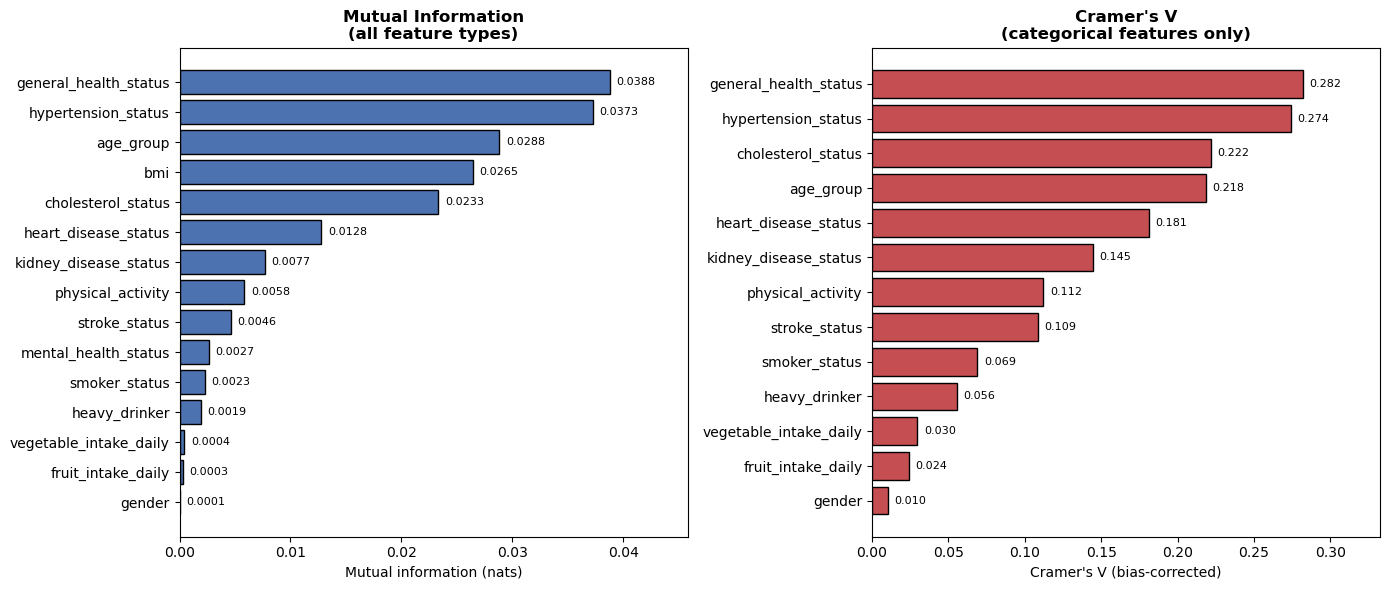

In [24]:
# visualise the association measures side by side for easier comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Mutual Information
mi_max = mi_df['mutual_info'].max()
mi_pad = mi_max * 0.015                    
axes[0].barh(mi_df['feature'][::-1], mi_df['mutual_info'][::-1],
             color='#4C72B0', edgecolor='black')
axes[0].set_title('Mutual Information\n(all feature types)',
                  fontweight='bold')
axes[0].set_xlabel('Mutual information (nats)')
axes[0].set_xlim(0, mi_max * 1.18)         
for i, v in enumerate(mi_df['mutual_info'][::-1]):
    axes[0].text(v + mi_pad, i, f'{v:.4f}', va='center', fontsize=8)

# Right: Cramer's V
v_max = v_df['cramers_v'].max()
v_pad = v_max * 0.015
axes[1].barh(v_df['feature'][::-1], v_df['cramers_v'][::-1],
             color='#C44E52', edgecolor='black')
axes[1].set_title("Cramer's V\n(categorical features only)",
                  fontweight='bold')
axes[1].set_xlabel("Cramer's V (bias-corrected)")
axes[1].set_xlim(0, v_max * 1.18)
for i, v in enumerate(v_df['cramers_v'][::-1]):
    axes[1].text(v + v_pad, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Phase 3: Data Preparation

## Phase 4: Modelling


## Phase 5: Evaluation


## Phase 6: Deployment

## Members' Contribution

| Member | Student ID | Contribution |
|--------|-----------|-------------|
| Aimi Sofiyah Binti Umar | 25088138 | Phase|
| Chin Yin Yin | 22003453 | Phase |
| Sakinah Al'Izzah Binti Mohd Asri | 25096564 | Phase|
| Nabilah Zieha Binti Sikh Mohamad | 25080732 | Phase|
| Gebriella A/P Anthony Suresh | 17204189 | Phase |

## References

- Groenwold, R. H. H., et al. (2012). Missing covariate data in clinical research: when and when not to use the missing-indicator method for analysis. CMAJ, 184(11), 1265–1269. https://www.cmaj.ca/content/184/11/1265

- Kang, H. (2013). The prevention and handling of the missing data. *Korean Journal of Anesthesiology*, 64(5), 402–406. https://pmc.ncbi.nlm.nih.gov/articles/PMC3668100/  

- Khaleel, F. A., et al. (2024). Robust predictive framework for diabetes classification using optimized machine learning on imbalanced datasets. *Frontiers in Artificial Intelligence*, 7. https://www.frontiersin.org/journals/artificial-intelligence/articles/10.3389/frai.2024.1499530/full  

- Lin, J., Bai, T., Zhou, S., & Tu, J. (2023). Empirical comparison of imputation methods for multivariate missing data in public health. *International Journal of Environmental Research and Public Health*, 20(2), 1524. https://www.mdpi.com/1660-4601/20/2/1524  

- Masconi, K. L., Matsha, T. E., Echouffo-Tcheugui, J. B., Erasmus, R. T., & Kengne, A. P. (2015). Reporting and handling of missing data in predictive research for prevalent undiagnosed type 2 diabetes mellitus: a systematic review. *EPMA Journal*, 6(7). https://pmc.ncbi.nlm.nih.gov/articles/PMC4380106/  

- Muhammad, M.A., Sani, J. & Ahmed, M.M. (2024). Exploring explainable machine learning for predicting and interpreting self-reported diabetes among Tennessee adults. https://pmc.ncbi.nlm.nih.gov/articles/PMC12669510/  

- Sperrin, M., Martin, G. P., Sisk, R., & Peek, N. (2020). Missing data should be handled differently for prediction than for description or causal explanation. Journal of Clinical Epidemiology, 125, 183–187. https://www.jclinepi.com/article/S0895-4356(19)30766-8/abstract